In [3]:
%cd /Users/safishajjouz/GitHub/QuantitativePortfolioManagement

/Users/safishajjouz/GitHub/QuantitativePortfolioManagement


In [4]:
import warnings
warnings.filterwarnings('ignore')

In [5]:
from myPortfolioManagement.myData import * 
from myPortfolioManagement.myPortfolioOptimisation import *
from myPortfolioManagement.myReturns import calculate_returns
from myPortfolioManagement.myPortfolioSelection import *
from myPortfolioManagement.myBacktesting import *

In [6]:
### load Data 
file = '/Users/safishajjouz/GitHub/QuantitativePortfolioManagement/myPortfolioManagement/Data/BBG_CommodityIndex.xlsx'

df_com_prices = pd.read_excel(file, sheet_name='USD_daily', skiprows = 6)
df_com_prices = df_com_prices.drop(['PX_VOLUME'], axis =1)
df_com_prices = df_com_prices.set_index('Date')
df_com_prices = df_com_prices.reindex(index=df_com_prices.index[::-1])
df_com_prices.head()

,PX_LAST
Date,
1960-01-04,14.8948
1960-01-05,14.8734
1960-01-06,14.9663
1960-01-07,14.9307
1960-01-08,14.9955


In [7]:
ret_comm = calculate_returns(df_com_prices)
ret_comm

,PX_LAST
Date,
1960-01-05,-0.001437
1960-01-06,0.006246
1960-01-07,-0.002379
1960-01-08,0.004340
1960-01-11,-0.001554
...,...
2022-02-24,0.008115
2022-02-25,-0.024894
2022-02-28,0.019170


## Working in progress: Functionality to adjust the chart so one can better see the fan charts when series are long

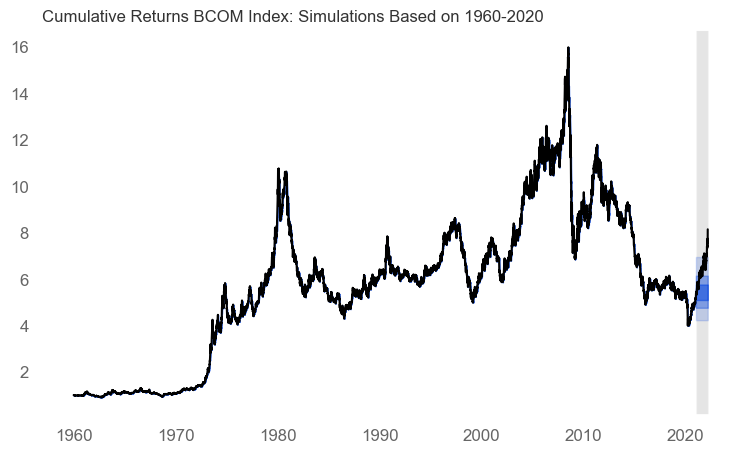

In [8]:
### create a fan chart 
fan_chart(returns = ret_comm['PX_LAST'], 
               weight_period = None,  ## this to bootstrap from specific regimes 
               out_of_sample_date = '2021-01-01', 
               n_sample = 1000,
               chart_title = 'Cumulative Returns BCOM Index: Simulations Based on 1960-2020' )


In [ ]:
### create a fan chart based on the distribution of a specific period: Here from 1970 - 1980
fan_chart(returns = ret_comm['PX_LAST'],  
               weight_period = ['1970-01-01', '1980-01-01'], 
               out_of_sample_date = '2021-01-01', 
               n_sample = 1000,
               chart_title = 'Cumulative Returns BCOM Index: Simulations Based on 1970-1980 (Stagflation Period)' )

In [ ]:
# get bootstrap stats 
bootstrap_stats(returns = ret_comm['PX_LAST'], 
                  returns_benchmark=None, 
                    rf = 0.02, 
                    periods = 252, 
                    n_sim = 1000)

In [ ]:
port_perf = bootstrap_portfolio_performance(returns = ret_comm['PX_LAST'], 
                                returns_benchmark = None,
                                periods = 252,
                                rf = 0.02, 
                                out_of_sample_date = '2020-01-01',  
                                n_sim = 1000)

In [ ]:
ret_sp = download_returns(yahoo_tickers = ['SMT.L', 'DBC', '^GSPC'])

port_perf2 = bootstrap_portfolio_performance(returns = ret_comm['PX_LAST'], 
                                returns_benchmark = ret_sp['SMT.L'],
                                periods = 252, # this is for annualisation 
                                rf = 0.02, 
                                out_of_sample_date = '2020-01-01',  
                                n_sim = 1000)


In [ ]:
port_perf2[0]

In [ ]:
port_perf2[1]